In [262]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


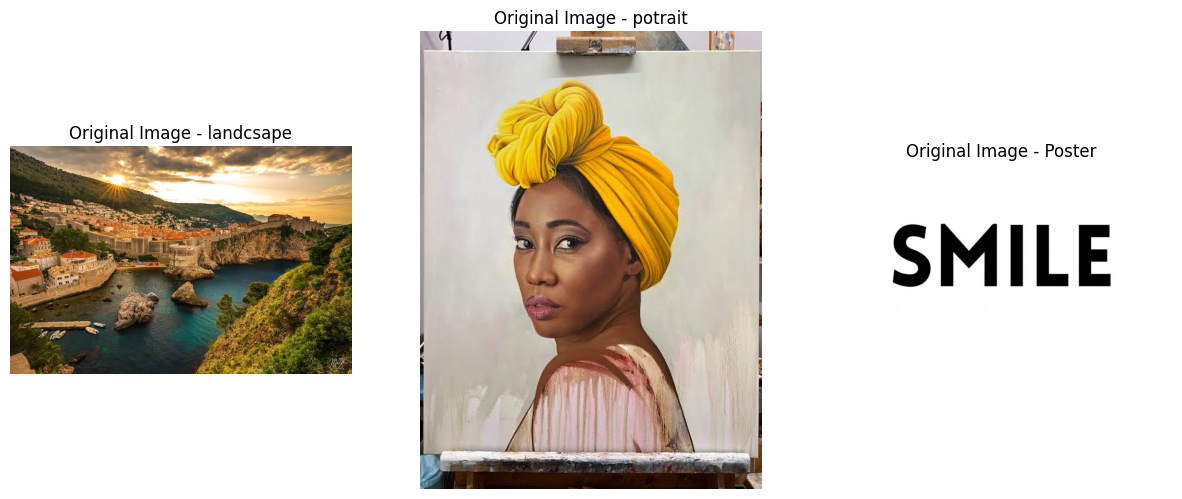

In [263]:
image = cv2.imread("images/buattugas1pcd_1.jpg")
image_rgb_ls = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 8))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb_ls)
plt.title("Original Image - landcsape")
plt.axis("off")

image2 = cv2.imread("images/buattugas1pcd_2.jpg")
image_rgb_pt = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

plt.subplot(1, 3, 2)
plt.imshow(image_rgb_pt)
plt.title("Original Image - potrait")
plt.axis("off")

image3 = cv2.imread("images/buattugas1pcd_3.jpg")
image_rgb_ps = cv2.cvtColor(image3, cv2.COLOR_BGR2RGB)

plt.subplot(1, 3, 3)
plt.imshow(image_rgb_ps)
plt.title("Original Image - Poster")
plt.axis("off")
plt.show()

#**Downscaling**

In this section, we will try three different methods of downscaling and compare their differeneces:

*   Max Pooling : which select the highest value pixel around neighboring pixels.
*   Average Pooling : which calculate the average of surrounding pixels.
*   Median Pooling : which selects the median of surrounding pixels





In [264]:
landscape_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def max_downsample(img, scale=2):
  h, w = img.shape
  new_h = h //scale
  new_w = w // scale

  res = np.zeros((new_h, new_w), dtype=img.dtype)

  for i in range(new_h):
    for j in range(new_w):
      block = img[
            i*scale:(i+1)*scale,
            j*scale:(j+1)*scale
      ]

      res[i, j] = np.max(block)

  return res

In [265]:
def max_downsample_color(img, scale=2):
    h, w, channels = img.shape

    new_h = h // scale
    new_w = w // scale

    res = np.zeros((new_h, new_w, channels), dtype=img.dtype)

    for i in range(new_h):
        for j in range(new_w):
            block = img[
                i*scale:(i+1)*scale,
                j*scale:(j+1)*scale
            ]

            res[i, j] = np.max(block, axis=(0, 1))

    return res

In [266]:
def avg_downsample(img, scale=2):
  h, w = img.shape
  new_h = h //scale
  new_w = w // scale

  res = np.zeros((new_h, new_w), dtype=np.float32)

  for i in range(new_h):
    for j in range(new_w):
      block = img[
            i*scale:(i+1)*scale,
            j*scale:(j+1)*scale
      ]

      res[i, j] = np.mean(block)

  return res.astype(np.uint8)

In [267]:
def avg_downsample_color(img, scale=2):
  h, w, channels = img.shape
  new_h = h //scale
  new_w = w // scale

  res = np.zeros((new_h, new_w, channels), dtype=np.float32)

  for i in range(new_h):
    for j in range(new_w):
      block = img[
            i*scale:(i+1)*scale,
            j*scale:(j+1)*scale
      ]

      res[i, j] = np.mean(block, axis=(0, 1))

  return res.astype(np.uint8)

In [268]:
def median_downsample(img, scale=2):
  h, w = img.shape
  new_h = h //scale
  new_w = w // scale

  res = np.zeros((new_h, new_w), dtype=img.dtype)

  for i in range(new_h):
    for j in range(new_w):
      block = img[
            i*scale:(i+1)*scale,
            j*scale:(j+1)*scale
      ]

      res[i, j] = np.median(block)

  return res

In [269]:
def median_downsample_color(img, scale=2):
  h, w, channels = img.shape
  new_h = h //scale
  new_w = w // scale

  res = np.zeros((new_h, new_w, channels), dtype=img.dtype)

  for i in range(new_h):
    for j in range(new_w):
      block = img[
            i*scale:(i+1)*scale,
            j*scale:(j+1)*scale
      ]

      res[i, j] = np.median(block, axis=(0,1))

  return res

In [270]:
max_res_ls = max_downsample(landscape_gray,2)
avg_res_ls = avg_downsample(landscape_gray, 2)
median_res_ls = median_downsample(landscape_gray, 2)

max_res_ls_color = max_downsample_color(image_rgb_ls,2)
avg_res_ls_color = avg_downsample_color(image_rgb_ls,2)
median_res_ls_color = median_downsample_color(image_rgb_ls,2)


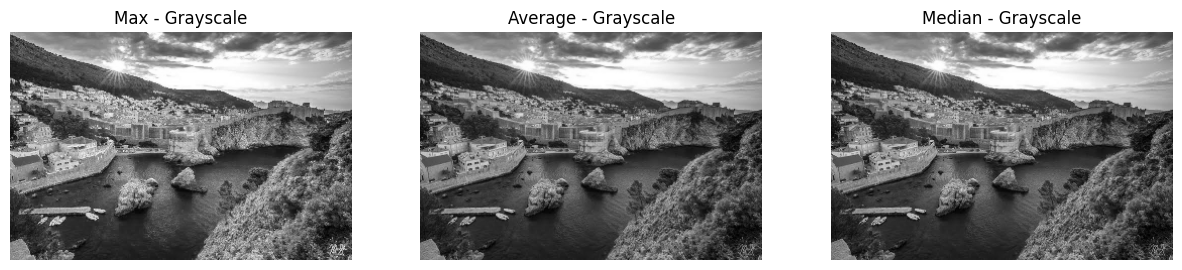

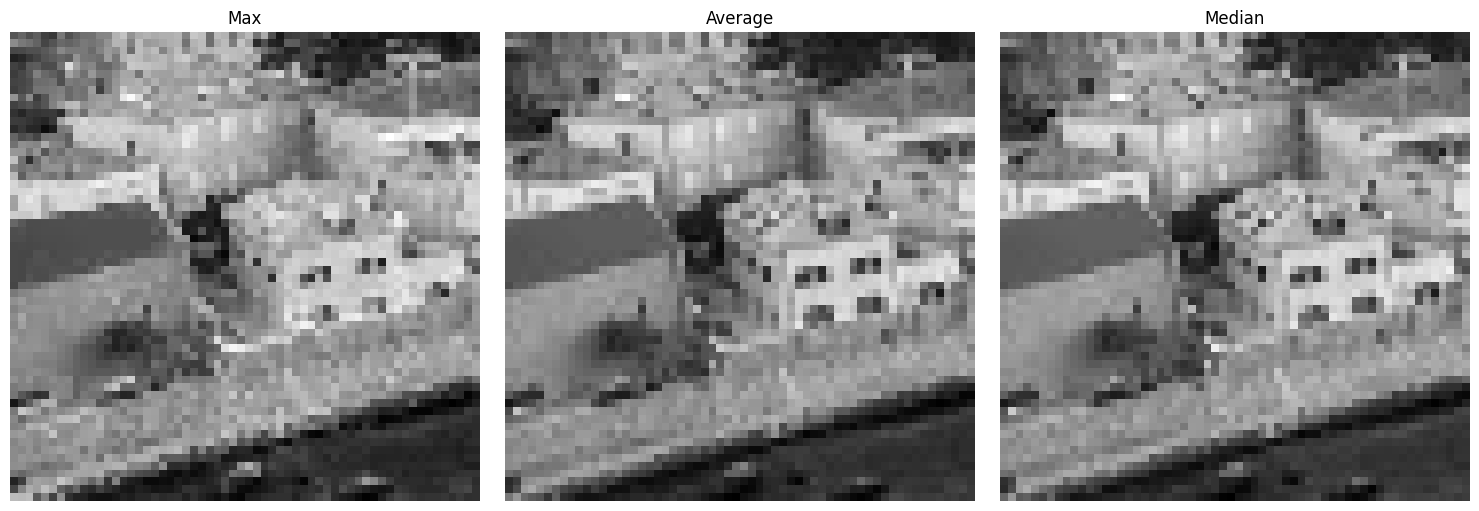

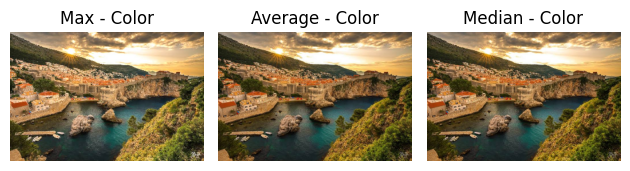

In [271]:
plt.figure(figsize=(15, 8))

# Grayscale
gray_results = [
    ("Max", max_res_ls),
    ("Average", avg_res_ls),
    ("Median", median_res_ls)
]

for i, (title, result) in enumerate(gray_results):
    plt.subplot(2, 3, i + 1)
    plt.imshow(result, cmap="gray")
    plt.title(title + " - Grayscale")
    plt.axis("off")

# crop
x1, x2 = 10, 70
y1, y2 = 100, 160

results = [
    ("Max", max_res_ls[y1:y2, x1:x2]),
    ("Average", avg_res_ls[y1:y2, x1:x2]),
    ("Median", median_res_ls[y1:y2, x1:x2])
]

plt.figure(figsize=(15, 5))

for i, (title, result) in enumerate(results):
    plt.subplot(1, 3, i + 1)
    plt.imshow(result, cmap = "gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


# Color
color_results = [
    ("Max", max_res_ls_color),
    ("Average", avg_res_ls_color),
    ("Median", median_res_ls_color)
]

for i, (title, result) in enumerate(color_results):
    plt.subplot(2, 3, i + 4)
    plt.imshow(result, cmap="gray")
    plt.title(title + " - Color")
    plt.axis("off")

plt.tight_layout()
plt.show()


(Before I begin, I also converted the image to grayscale for a much more convenient comparison as it is more obvious in term values differences compared with RGB channels)

In the image that has done a max_downsample, there's a decrease of lightness in certain areas compared to other downsamples. It is also 'crispier' in term of quality. The pixelated area are much more apparent then it is in others. That is because it reserved the highest pixel values in surrounding pixel areas. As a result, bright areas and strong highlight are more prominent.

While in average and median, there are barely any differences at first glance. Both offers a much more smoother image then max_downsample as they offer a similar 'in the middle' representation (of course it is not truly the case... as median and average are two different thing, but both do talk about the 'in the middle' value of a set of data, in a way).

In avg_downsample, the output of each pixel is a calculated average of the neighboring pixels. Hence it resulted in a smoother transition. However, fine details and sharp edges loses can lose its characteristic because a high-frequency information is averaged with surrounding pixels.

In med_downsample on the other hand selects a middle value of the neighboring pixels, so that it is less affected by extreme pixel values when an image contains noise or isolated bright or dark pixels. However, similar to avg_downsample, it could lose fine details in the process.

Now that settled, let's test it with other images.

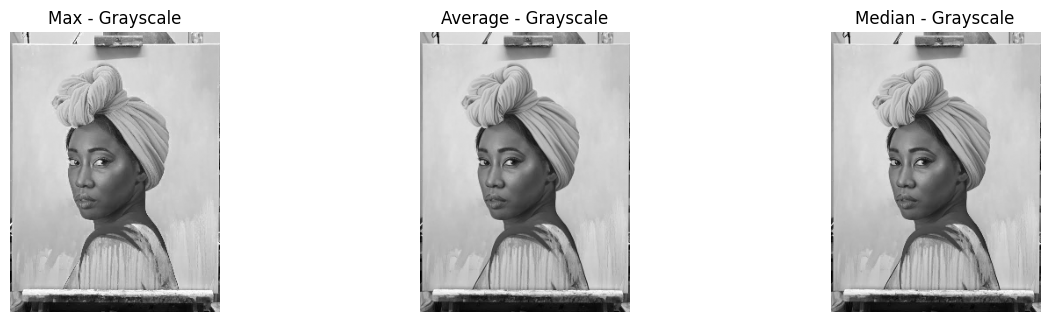

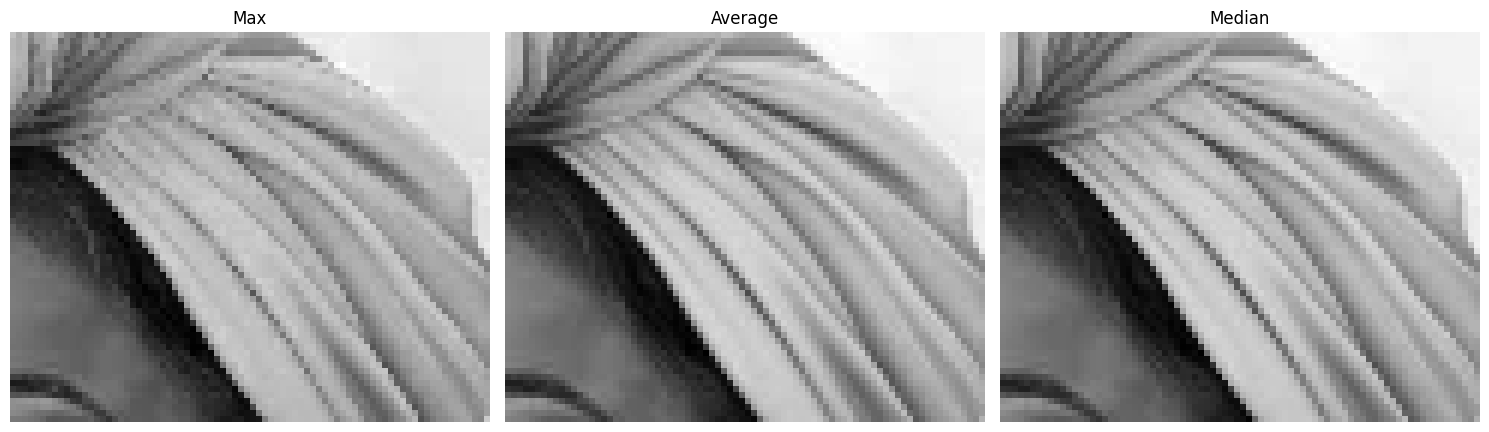

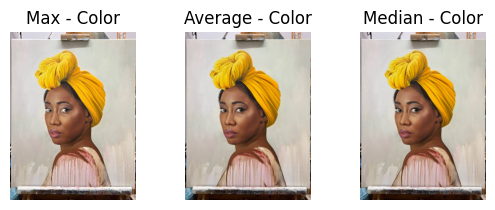

In [282]:
potrait_gray = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

max_res_pt = max_downsample(potrait_gray,2)
avg_res_pt = avg_downsample(potrait_gray, 2)
median_res_pt = median_downsample(potrait_gray, 2)

max_res_pt_color = max_downsample_color(image_rgb_pt,2)
avg_res_pt_color = avg_downsample_color(image_rgb_pt, 2)
median_res_pt_color = median_downsample_color(image_rgb_pt, 2)

plt.figure(figsize=(15, 8))

# Grayscale
gray_results = [
    ("Max", max_res_pt),
    ("Average", avg_res_pt),
    ("Median", median_res_pt)
]

for i, (title, result) in enumerate(gray_results):
    plt.subplot(2, 3, i + 1)
    plt.imshow(result, cmap="gray")
    plt.title(title + " - Grayscale")
    plt.axis("off")

# crop
x1, x2 = 100, 180
y1, y2 = 75, 140

results = [
    ("Max", max_res_pt[y1:y2, x1:x2]),
    ("Average", avg_res_pt[y1:y2, x1:x2]),
    ("Median", median_res_pt[y1:y2, x1:x2])
]

plt.figure(figsize=(15, 5))

for i, (title, result) in enumerate(results):
    plt.subplot(1, 3, i + 1)
    plt.imshow(result, cmap = "gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Color
color_results = [
    ("Max", max_res_pt_color),
    ("Average", avg_res_pt_color),
    ("Median", median_res_pt_color)
]

for i, (title, result) in enumerate(color_results):
    plt.subplot(2, 3, i + 4)
    plt.imshow(result, cmap="gray")
    plt.title(title + " - Color")
    plt.axis("off")

plt.show()

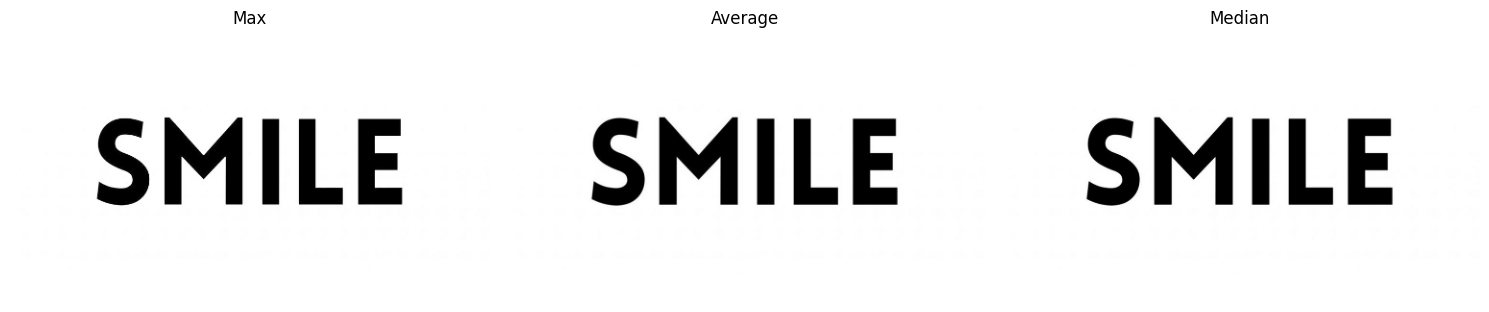

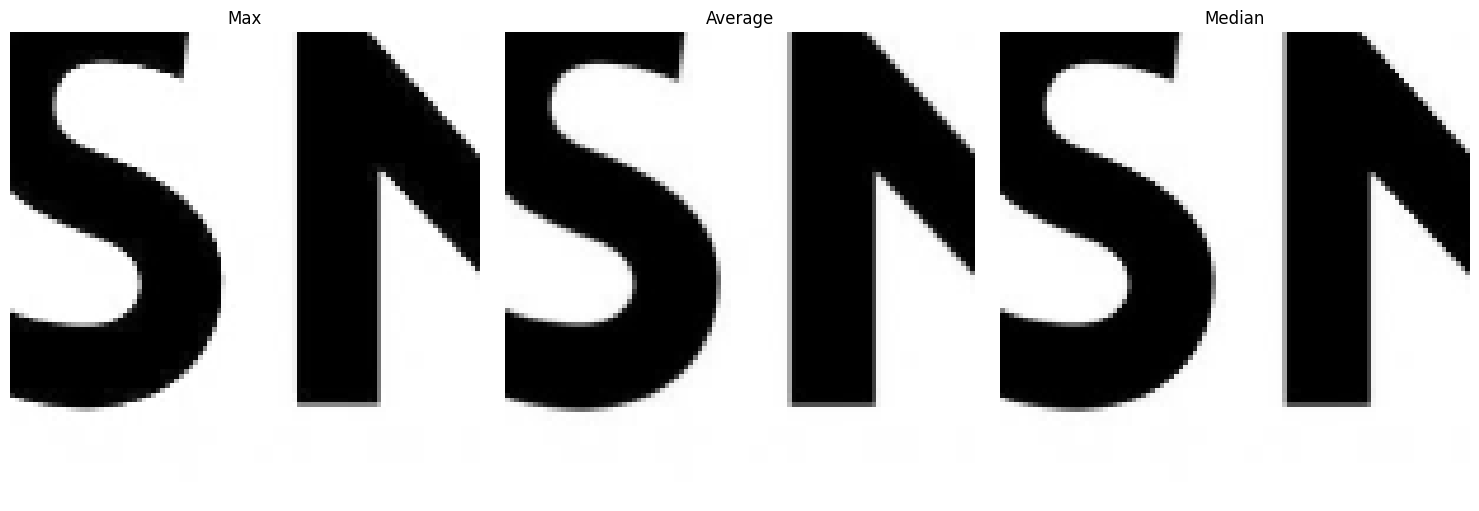

In [283]:
poster_gray = cv2.cvtColor(image3, cv2.COLOR_BGR2GRAY)

max_res_ps = max_downsample(poster_gray, 2)
avg_res_ps = avg_downsample(poster_gray, 2)
median_res_ps = median_downsample(poster_gray, 2)

results = [
    ("Max", max_res_ps),
    ("Average", avg_res_ps),
    ("Median", median_res_ps)
]

plt.figure(figsize=(15, 5))

for i, (title, result) in enumerate(results):
    plt.subplot(1, 3, i + 1)
    plt.imshow(result, cmap = "gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

# crop
x1, x2 = 100, 200
y1, y2 = 100, 200

results = [
    ("Max", max_res_ps[y1:y2, x1:x2]),
    ("Average", avg_res_ps[y1:y2, x1:x2]),
    ("Median", median_res_ps[y1:y2, x1:x2])
]

plt.figure(figsize=(15, 5))

for i, (title, result) in enumerate(results):
    plt.subplot(1, 3, i + 1)
    plt.imshow(result, cmap = "gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

#**Upscaling**
In this section, we will try three different methods of upscaling and compare their differences:

* Nearest Neighbor: which assigns each new pixel the value of the nearest pixel in the original image.
* Bilinear: which calculates the value of each new pixel based on the weighted average of the surrounding pixels.
* Bicubic: calculates each new pixel using a larger group of surrounding pixels and cubic interpolation, resulting in smoother details.


In [274]:
def upscale(img, scale=2):
    h, w = img.shape[:2]

    new_w = w * scale
    new_h = h * scale

    nn = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_NEAREST
    )

    bilinear = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR
    )

    bicubic = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_CUBIC
    )

    return nn, bilinear, bicubic

In [275]:
def upscale_color(img, scale=2):
    h, w = img.shape[:2]

    new_w = w * scale
    new_h = h * scale

    nn = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_NEAREST
    )

    bilinear = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR
    )

    bicubic = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_CUBIC
    )

    return nn, bilinear, bicubic

In [276]:
#landscape
nn_result_color, bilinear_result_color, bicubic_result_color = upscale_color(
    image_rgb_ls,
    scale=2
)

nn_result, bilinear_result, bicubic_result = upscale(
    landscape_gray,
    scale=2
)

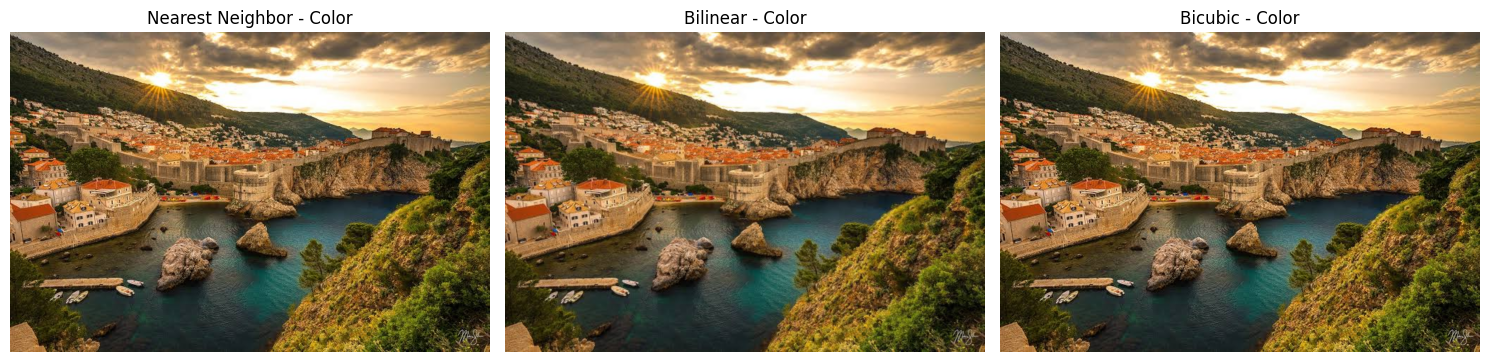

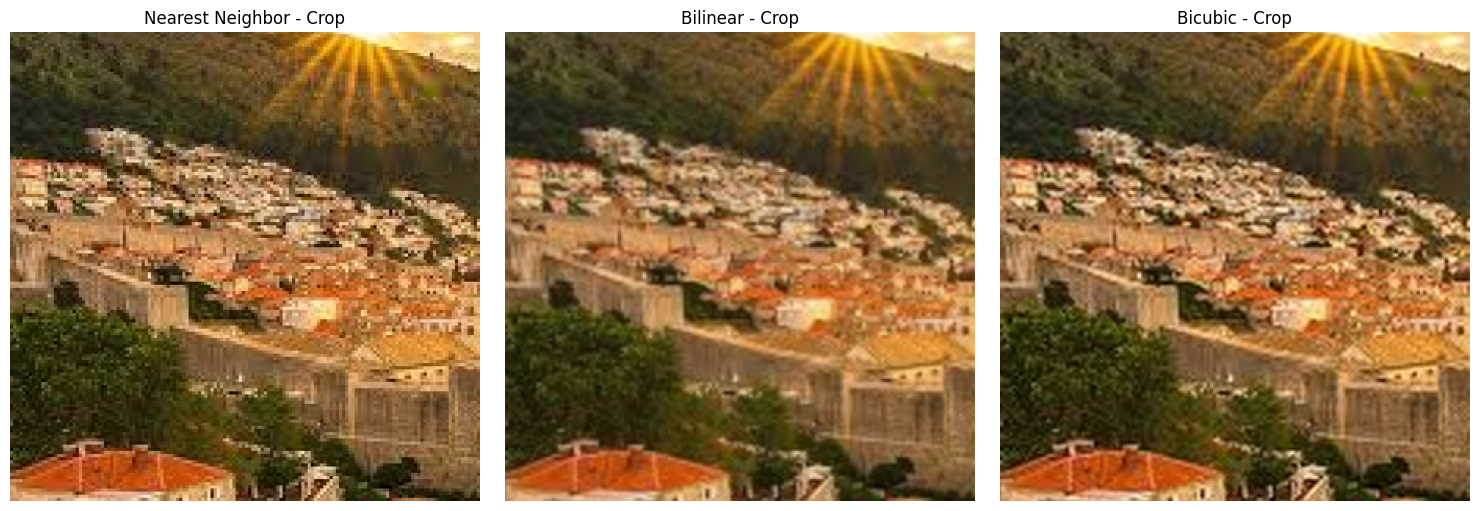

In [277]:
plt.figure(figsize=(15, 8))
color_results = [
    ("Nearest Neighbor", nn_result_color),
    ("Bilinear", bilinear_result_color),
    ("Bicubic", bicubic_result_color)
]

for i, (title, result) in enumerate(color_results):
    plt.subplot(2, 3, i + 4)
    plt.imshow(result, cmap="gray")
    plt.title(title + " - Color")
    plt.axis("off")

plt.tight_layout()
plt.show()

# crop
x1, x2 = 200, 500
y1, y2 = 150, 450

color_results = [
    ("Nearest Neighbor", nn_result_color[y1:y2, x1:x2]),
    ("Bilinear", bilinear_result_color[y1:y2, x1:x2]),
    ("Bicubic", bicubic_result_color[y1:y2, x1:x2])
]

plt.figure(figsize=(15, 5))

for i, (title, result) in enumerate(color_results):
    plt.subplot(1, 3, i + 1)
    plt.imshow(result)
    plt.title(title + " - Crop")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [278]:
#potrait
nn_result_color, bilinear_result_color, bicubic_result_color = upscale_color(
    image_rgb_pt,
    scale=2
)

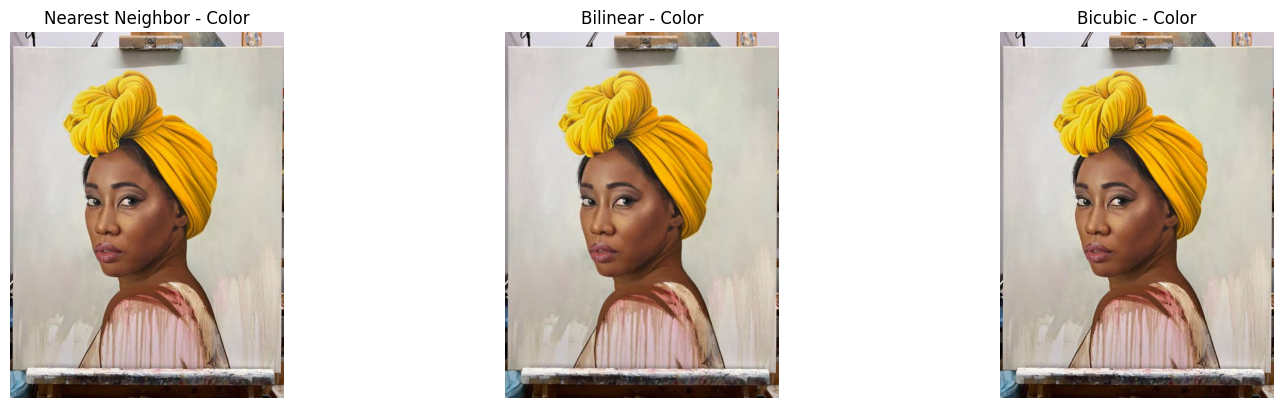

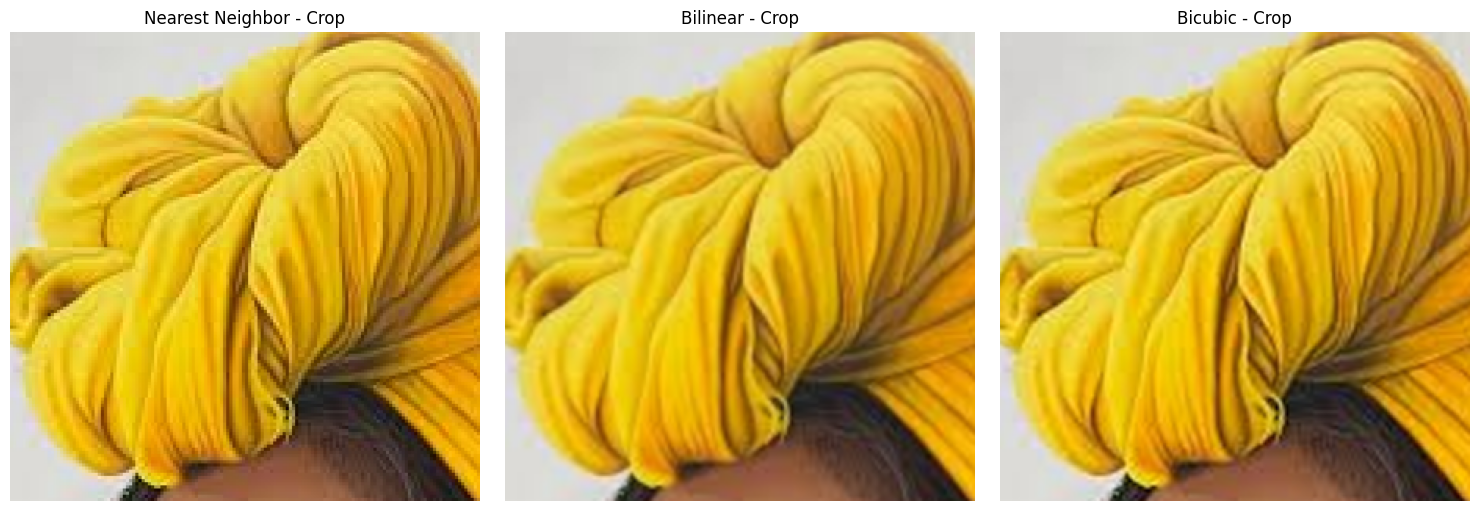

In [279]:
plt.figure(figsize=(15, 8))

color_results = [
    ("Nearest Neighbor", nn_result_color),
    ("Bilinear", bilinear_result_color),
    ("Bicubic", bicubic_result_color)
]

for i, (title, result) in enumerate(color_results):
    plt.subplot(2, 3, i + 4)
    plt.imshow(result, cmap="gray")
    plt.title(title + " - Color")
    plt.axis("off")

plt.tight_layout()
plt.show()

# crop
x1, x2 = 200, 500
y1, y2 = 150, 450

color_results = [
    ("Nearest Neighbor", nn_result_color[y1:y2, x1:x2]),
    ("Bilinear", bilinear_result_color[y1:y2, x1:x2]),
    ("Bicubic", bicubic_result_color[y1:y2, x1:x2])
]

plt.figure(figsize=(15, 5))

for i, (title, result) in enumerate(color_results):
    plt.subplot(1, 3, i + 1)
    plt.imshow(result)
    plt.title(title + " - Crop")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [280]:
#poster
nn_result_color, bilinear_result_color, bicubic_result_color = upscale_color(
    image_rgb_ps,
    scale=2
)

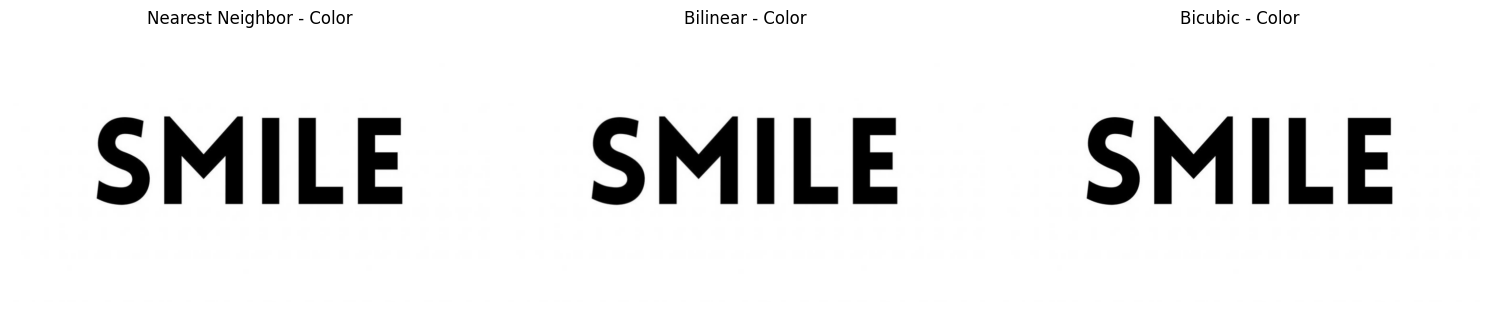

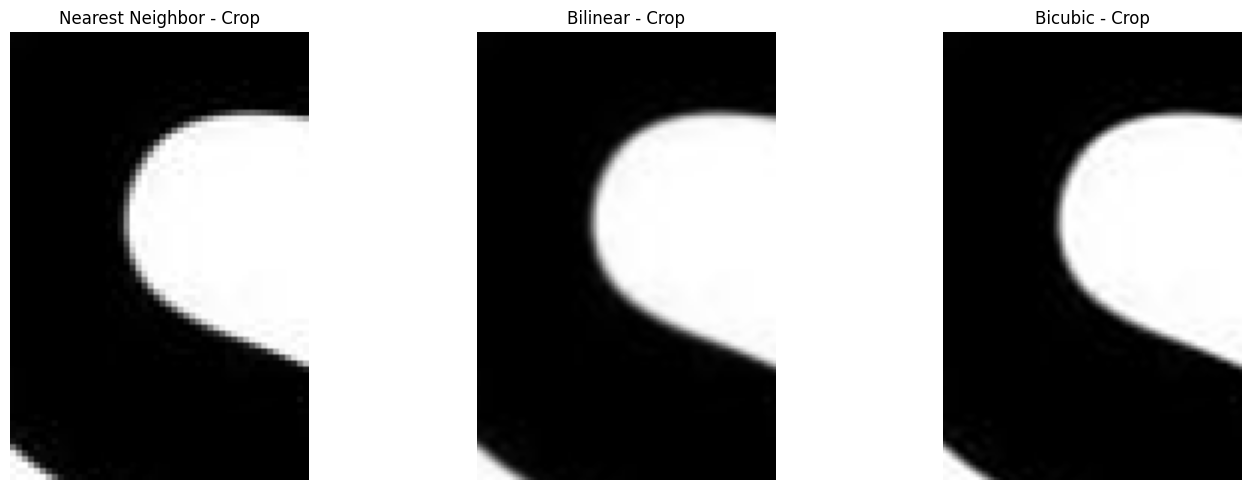

In [281]:
plt.figure(figsize=(15, 8))

color_results = [
    ("Nearest Neighbor", nn_result_color),
    ("Bilinear", bilinear_result_color),
    ("Bicubic", bicubic_result_color)
]

for i, (title, result) in enumerate(color_results):
    plt.subplot(2, 3, i + 4)
    plt.imshow(result, cmap="gray")
    plt.title(title + " - Color")
    plt.axis("off")

plt.tight_layout()
plt.show()

# crop
x1, x2 = 400, 500
y1, y2 = 400, 550

color_results = [
    ("Nearest Neighbor", nn_result_color[y1:y2, x1:x2]),
    ("Bilinear", bilinear_result_color[y1:y2, x1:x2]),
    ("Bicubic", bicubic_result_color[y1:y2, x1:x2])
]

plt.figure(figsize=(15, 5))

for i, (title, result) in enumerate(color_results):
    plt.subplot(1, 3, i + 1)
    plt.imshow(result)
    plt.title(title + " - Crop")
    plt.axis("off")

plt.tight_layout()
plt.show()